# Random Forest Multi-Horizon Forecasting of Daily PM$_{2.5}$
## London Marylebone Road

### Research objective

This notebook implements a **direct multi-horizon Random Forest regression framework** for forecasting daily PM$_{2.5}$ concentrations at lead times of **1, 7, 14, and 30 days**. The central modelling question is whether a non-linear ensemble of decision trees can retain useful predictive skill as the forecast horizon increases, while remaining interpretable and robust under a strictly chronological evaluation design.

For each horizon $h \in \{1,7,14,30\}$, a separate model is estimated:

$$
\hat{y}_{t+h}=f_h(\mathbf{x}_t),
$$

where $\mathbf{x}_t$ denotes the predictor vector available at forecast origin $t$, and $y_{t+h}$ is the observed PM$_{2.5}$ concentration $h$ days later.

The analysis emphasises four principles: **temporal integrity**, **out-of-sample evaluation**, **comparison with a persistence benchmark**, and **post-hoc model interpretability**.


In [1]:
# ============================================================
# RANDOM FOREST – MULTI-HORIZON PM2.5 FORECASTING
# London Marylebone Road
#
# Direct forecast horizons:
# 1 day, 7 days, 14 days and 30 days ahead
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")


## Experimental configuration and reproducibility

The experiment is configured once and then reused consistently across all forecast horizons. A fixed random seed is specified to make stochastic components of model fitting and hyperparameter search reproducible. Model artefacts, prediction files, and evaluation outputs are written to dedicated directories so that the complete forecasting workflow can be audited and reproduced.

The target variable is daily PM$_{2.5}$. The date field and contemporaneous target are excluded from the predictor matrix itself, while engineered temporal, lagged-pollution, and meteorological variables remain available as candidate predictors.

In [2]:

# ============================================================
# 2. CONFIGURATION
# ============================================================

# Dataset folder
# Your london_final_dataset folder is in the same directory
# as the Random Forest notebook.
DATA_DIR = Path("london_final_dataset")

# Target variable
TARGET = "pm25"

# Columns excluded from model predictors
DROP_COLS = ["date", TARGET]

# Folder for saved Random Forest models
MODEL_DIR = Path("saved_con_rf")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Folder for results, predictions and figures
RESULTS_DIR = Path("rf_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Forecast horizons
FORECAST_HORIZONS = [1, 7, 14, 30]

# Reproducibility
RANDOM_STATE = 42

In [5]:

# ============================================================
# 3. DATASET PATHS
# ============================================================

TRAIN_PATH = DATA_DIR / "marylebone_train.csv"
TEST_PATH = DATA_DIR / "marylebone_test.csv"
ALL_PATH = DATA_DIR / "marylebone_all.csv"

print("Current directory :", Path.cwd())
print("Dataset directory :", DATA_DIR.resolve())
print("Model directory   :", MODEL_DIR.resolve())
print("Results directory :", RESULTS_DIR.resolve())

Current directory : /Users/hirunikeshika/AIR/notebooks
Dataset directory : /Users/hirunikeshika/AIR/notebooks/london_final_dataset
Model directory   : /Users/hirunikeshika/AIR/notebooks/saved_con_rf
Results directory : /Users/hirunikeshika/AIR/notebooks/rf_results


In [7]:
# ============================================================
# 4. CHECK FILES
# ============================================================

required_files = [
    TRAIN_PATH,
    TEST_PATH,
    ALL_PATH
]

for file_path in required_files:

    if not file_path.exists():

        raise FileNotFoundError(
            f"File not found: {file_path}\n"
            "Check the exact CSV filename inside "
            "london_final_dataset."
        )

print("\nAll required dataset files were found.")


All required dataset files were found.


## Data ingestion and temporal partitioning

The modelling pipeline uses pre-defined training, test, and complete datasets. Dates are parsed explicitly, observations are sorted chronologically, and the train/test boundaries are derived from the data rather than assumed manually.

This chronological separation is essential for time-series forecasting: the holdout period represents genuinely unseen future observations and must not influence model fitting, hyperparameter selection, or feature engineering decisions that would be unavailable at the forecast origin.


In [9]:
# ============================================================
# 5. LOAD DATASETS
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
df = pd.read_csv(ALL_PATH)

print("\nDataset dimensions")
print("-" * 50)
print("Training :", train_df.shape)
print("Testing  :", test_df.shape)
print("Complete :", df.shape)

display(train_df.head())


Dataset dimensions
--------------------------------------------------
Training : (1000, 42)
Testing  : (364, 42)
Complete : (1364, 42)


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


In [11]:
# ============================================================
# 6. DATE PREPARATION
# ============================================================

for dataset in [train_df, test_df, df]:

    dataset["date"] = pd.to_datetime(
        dataset["date"],
        errors="raise"
    )

    dataset.sort_values(
        "date",
        inplace=True
    )

    dataset.reset_index(
        drop=True,
        inplace=True
    )


print("\nTraining period:")
print(
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)

print("\nTesting period:")
print(
    test_df["date"].min(),
    "to",
    test_df["date"].max()
)


Training period:
2022-04-07 00:00:00 to 2024-12-31 00:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-30 00:00:00


In [13]:
# ============================================================
# 7. TRAIN / TEST BOUNDARIES
# ============================================================

TRAIN_END = train_df["date"].max()
TEST_START = test_df["date"].min()
TEST_END = test_df["date"].max()

print("\nChronological boundaries")
print("-" * 50)
print("Training ends :", TRAIN_END)
print("Testing starts:", TEST_START)
print("Testing ends  :", TEST_END)


Chronological boundaries
--------------------------------------------------
Training ends : 2024-12-31 00:00:00
Testing starts: 2025-01-01 00:00:00
Testing ends  : 2025-12-30 00:00:00


## Data quality and temporal integrity checks

Before modelling, the notebook performs structural checks on the daily time series. Missing values, duplicate dates, and discontinuities in the daily sequence are inspected because each can alter the meaning of lagged predictors and future-shifted targets.

A forecasting dataset should preserve the temporal relationship between $t$ and $t+h$. Duplicate timestamps or unrecognised gaps can break that relationship and may therefore introduce misaligned targets or misleading estimates of predictive performance. These checks are treated as part of the experimental validity procedure rather than as optional exploratory diagnostics.


In [15]:
# ============================================================
# 8. DATA QUALITY CHECKS
# ============================================================

print("\nData quality checks")
print("-" * 50)

print(
    "Total missing values:",
    df.isna().sum().sum()
)

print(
    "Duplicate dates:",
    df["date"].duplicated().sum()
)

print("\nPM2.5 summary:")
display(df[TARGET].describe())


if df["date"].duplicated().any():

    raise ValueError(
        "Duplicate dates were detected. "
        "Resolve duplicate observations before modelling."
    )


Data quality checks
--------------------------------------------------
Total missing values: 0
Duplicate dates: 0

PM2.5 summary:


count    1364.000000
mean        8.678425
std         5.663031
min         1.800000
25%         5.400000
50%         6.895000
75%         9.662500
max        59.800000
Name: pm25, dtype: float64

In [17]:

# ============================================================
# 9. CHECK TIME-SERIES CONTINUITY
# ============================================================

date_differences = (
    df["date"]
    .sort_values()
    .diff()
    .dropna()
)

non_daily_gaps = date_differences[
    date_differences != pd.Timedelta(days=1)
]

print(
    "\nNumber of non-daily gaps:",
    len(non_daily_gaps)
)

if len(non_daily_gaps) > 0:

    print(
        "WARNING: The dataset contains non-daily gaps."
    )



Number of non-daily gaps: 0


## Predictor representation

The predictor set combines multiple information sources, including calendar structure, cyclical temporal encodings, recent PM$_{2.5}$ behaviour, and meteorological conditions. All model inputs are verified to be numeric before estimation.

Random Forest does not require feature standardisation because tree splits depend on ordered thresholds rather than Euclidean distance. This allows variables measured on different physical scales to be modelled directly. Nevertheless, redundant or highly correlated predictors can distribute importance across related variables; consequently, feature-importance values are interpreted as model-dependent evidence rather than causal effects.


In [19]:
# ============================================================
# 10. DEFINE FEATURES
# ============================================================

# Remove date and target.
features = [
    column
    for column in df.columns
    if column not in DROP_COLS
]

print("\nNumber of predictor variables:", len(features))

print("\nPredictors:")

for feature in features:
    print(feature)


Number of predictor variables: 40

Predictors:
year
month
day_of_month
day_of_week_x
day_of_year
week_of_year
quarter
is_weekend
is_weekday
season_code
month_sin
month_cos
doy_sin
doy_cos
dow_sin
dow_cos
week_sin
week_cos
pm25_lag1
pm25_lag7
pm25_rollmean3
pm25_rollstd3
day_of_week_y
quarter_num
mean_relative_humidity_pct
relative_humidity_max_pct
relative_humidity_min_pct
total_precipitation_mm
precipitation_max_mm
precipitation_min_mm
mean_air_pressure_hpa
air_pressure_max_hpa
air_pressure_min_hpa
temperature_max_c
temperature_min_c
temperature_avg_c
mean_wind_speed_knots
wind_speed_max_knots
wind_speed_min_knots
wind_direction_deg


In [21]:
# ============================================================
# 11. CHECK THAT ALL PREDICTORS ARE NUMERIC
# ============================================================

non_numeric_features = (
    df[features]
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

if non_numeric_features:

    raise ValueError(
        "The following predictors are non-numeric: "
        f"{non_numeric_features}"
    )

print("\nAll predictors are numeric.")


All predictors are numeric.


## Random Forest specification and hyperparameter optimisation

Random Forest regression combines predictions from many decorrelated decision trees. The ensemble can represent non-linear relationships and higher-order interactions without requiring an explicit parametric functional form. This is appropriate for atmospheric data, where pollutant concentrations may respond non-linearly to recent pollution levels, wind, temperature, pressure, humidity, precipitation, and seasonal structure.

The hyperparameter search explores tree count, maximum depth, minimum split size, minimum leaf size, and the number of predictors considered at each split. Hyperparameters are selected using **RandomizedSearchCV** with **negative MAE** as the optimisation criterion. Random search provides broader coverage of the candidate space than a small manual search while remaining computationally tractable.


In [23]:
# ============================================================
# 12. RANDOM FOREST HYPERPARAMETER SEARCH SPACE
# ============================================================

PARAMETER_GRID = {

    "n_estimators": [
        200,
        300,
        500,
        700
    ],

    "max_depth": [
        None,
        8,
        12,
        16,
        20
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        0.5,
        0.8
    ],

    "bootstrap": [
        True
    ]
}


In [25]:
# ============================================================
# 13. STORAGE
# ============================================================

results = []

best_models = {}

prediction_data = {}

mdi_importance_data = {}

permutation_importance_data = {}

In [27]:
# ============================================================
# 14. TRAIN RANDOM FOREST FOR EACH FORECAST HORIZON
# ============================================================

for horizon in FORECAST_HORIZONS:

    print("\n")
    print("=" * 75)
    print(
        f"RANDOM FOREST – {horizon}-DAY-AHEAD FORECAST"
    )
    print("=" * 75)


    # ========================================================
    # 14.1 CREATE FUTURE TARGET
    # ========================================================

    data = df.copy()

    target_column = (
        f"target_pm25_{horizon}d"
    )

    target_date_column = (
        f"target_date_{horizon}d"
    )


    # Features at time t predict PM2.5 at t + horizon
    data[target_column] = (
        data[TARGET]
        .shift(-horizon)
    )

    data[target_date_column] = (
        data["date"]
        .shift(-horizon)
    )


    # ========================================================
    # 14.2 REMOVE ROWS WITHOUT FUTURE TARGETS
    # ========================================================

    data = data.dropna(
        subset=[
            target_column,
            target_date_column
        ]
    ).copy()


    # ========================================================
    # 14.3 CREATE TRAINING SET
    # ========================================================
    #
    # The forecast origin and forecast target must both
    # remain inside the original training period.
    #
    # This prevents 2025 target values from entering training.
    # ========================================================

    train_data = data[
        (data["date"] <= TRAIN_END)
        &
        (data[target_date_column] <= TRAIN_END)
    ].copy()


    # ========================================================
    # 14.4 CREATE TEST SET
    # ========================================================

    test_data = data[
        (data["date"] >= TEST_START)
        &
        (data["date"] <= TEST_END)
        &
        (data[target_date_column] <= TEST_END)
    ].copy()


    print(
        "Training observations:",
        len(train_data)
    )

    print(
        "Testing observations :",
        len(test_data)
    )


    # ========================================================
    # 14.5 PREPARE X AND y
    # ========================================================

    X_train = train_data[
        features
    ].copy()

    y_train = train_data[
        target_column
    ].copy()

    X_test = test_data[
        features
    ].copy()

    y_test = test_data[
        target_column
    ].copy()


    # ========================================================
    # 14.6 SAFETY CHECKS
    # ========================================================

    if X_train.isna().any().any():

        raise ValueError(
            f"Missing predictor values found "
            f"in {horizon}-day training data."
        )

    if X_test.isna().any().any():

        raise ValueError(
            f"Missing predictor values found "
            f"in {horizon}-day testing data."
        )


    # ========================================================
    # 14.7 HORIZON-AWARE TIME-SERIES CROSS-VALIDATION
    # ========================================================
    #
    # The gap separates the end of each training fold
    # from its validation fold.
    #
    # ========================================================

    tscv = TimeSeriesSplit(
        n_splits=5,
        gap=horizon
    )


    # ========================================================
    # 14.8 INITIAL RANDOM FOREST
    # ========================================================

    rf = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


    # ========================================================
    # 14.9 HYPERPARAMETER TUNING
    # ========================================================

    search = RandomizedSearchCV(

        estimator=rf,

        param_distributions=PARAMETER_GRID,

        n_iter=30,

        scoring="neg_mean_absolute_error",

        cv=tscv,

        random_state=RANDOM_STATE,

        n_jobs=-1,

        verbose=1,

        refit=True
    )


    print("\nHyperparameter optimisation started...")


    search.fit(
        X_train,
        y_train
    )


    # Best model
    best_rf = search.best_estimator_

    best_models[horizon] = best_rf


    # Best cross-validation MAE
    best_cv_mae = -search.best_score_


    print("\nBest hyperparameters:")

    for parameter, value in search.best_params_.items():

        print(
            f"{parameter}: {value}"
        )


    print(
        f"\nBest CV MAE: {best_cv_mae:.4f}"
    )


    # ========================================================
    # 14.10 TEST-SET PREDICTIONS
    # ========================================================

    y_pred = best_rf.predict(
        X_test
    )


    # ========================================================
    # 14.11 RANDOM FOREST PERFORMANCE
    # ========================================================

    y_true = y_test.to_numpy()


    # Mean Absolute Error
    rf_mae = mean_absolute_error(
        y_true,
        y_pred
    )


    # Mean Squared Error
    rf_mse = mean_squared_error(
        y_true,
        y_pred
    )


    # Root Mean Squared Error
    rf_rmse = np.sqrt(
        rf_mse
    )


    # R-squared
    rf_r2 = r2_score(
        y_true,
        y_pred
    )


    # Mean Absolute Percentage Error
    rf_mape = (
        np.mean(
            np.abs(
                (y_true - y_pred)
                /
                np.maximum(
                    np.abs(y_true),
                    1e-8
                )
            )
        )
        * 100
    )


    # Mean Bias Error
    # Positive = overprediction
    # Negative = underprediction
    rf_mbe = np.mean(
        y_pred - y_true
    )


    # ========================================================
    # 14.12 PERSISTENCE BASELINE
    # ========================================================
    #
    # Baseline:
    #
    # PM2.5(t+h) = PM2.5(t)
    #
    # ========================================================

    persistence_pred = (
        test_data[TARGET]
        .to_numpy()
    )


    baseline_mae = mean_absolute_error(
        y_true,
        persistence_pred
    )


    baseline_mse = mean_squared_error(
        y_true,
        persistence_pred
    )


    baseline_rmse = np.sqrt(
        baseline_mse
    )


    baseline_r2 = r2_score(
        y_true,
        persistence_pred
    )


    baseline_mape = (
        np.mean(
            np.abs(
                (y_true - persistence_pred)
                /
                np.maximum(
                    np.abs(y_true),
                    1e-8
                )
            )
        )
        * 100
    )


    baseline_mbe = np.mean(
        persistence_pred - y_true
    )


    # ========================================================
    # 14.13 IMPROVEMENT OVER BASELINE
    # ========================================================

    mae_improvement_pct = (
        (
            baseline_mae - rf_mae
        )
        /
        baseline_mae
        * 100
    )


    rmse_improvement_pct = (
        (
            baseline_rmse - rf_rmse
        )
        /
        baseline_rmse
        * 100
    )


    # ========================================================
    # 14.14 PRINT PERFORMANCE
    # ========================================================

    print("\nRandom Forest performance")
    print("-" * 45)

    print(
        f"MAE : {rf_mae:.4f}"
    )

    print(
        f"MSE : {rf_mse:.4f}"
    )

    print(
        f"RMSE: {rf_rmse:.4f}"
    )

    print(
        f"R²  : {rf_r2:.4f}"
    )

    print(
        f"MAPE: {rf_mape:.2f}%"
    )

    print(
        f"MBE : {rf_mbe:.4f}"
    )


    print("\nPersistence baseline")
    print("-" * 45)

    print(
        f"MAE : {baseline_mae:.4f}"
    )

    print(
        f"MSE : {baseline_mse:.4f}"
    )

    print(
        f"RMSE: {baseline_rmse:.4f}"
    )

    print(
        f"R²  : {baseline_r2:.4f}"
    )

    print(
        f"MAPE: {baseline_mape:.2f}%"
    )

    print(
        f"MBE : {baseline_mbe:.4f}"
    )


    print("\nImprovement over persistence")
    print("-" * 45)

    print(
        f"MAE improvement : "
        f"{mae_improvement_pct:.2f}%"
    )

    print(
        f"RMSE improvement: "
        f"{rmse_improvement_pct:.2f}%"
    )


    # ========================================================
    # 14.15 STORE PERFORMANCE
    # ========================================================

    results.append({

        "Horizon_Days":
            horizon,

        "Model":
            "Random Forest",

        "Training_Observations":
            len(train_data),

        "Testing_Observations":
            len(test_data),

        "CV_MAE":
            best_cv_mae,

        "MAE":
            rf_mae,

        "MSE":
            rf_mse,

        "RMSE":
            rf_rmse,

        "R2":
            rf_r2,

        "MAPE":
            rf_mape,

        "MBE":
            rf_mbe,

        "Persistence_MAE":
            baseline_mae,

        "Persistence_MSE":
            baseline_mse,

        "Persistence_RMSE":
            baseline_rmse,

        "Persistence_R2":
            baseline_r2,

        "Persistence_MAPE":
            baseline_mape,

        "Persistence_MBE":
            baseline_mbe,

        "MAE_Improvement_Percent":
            mae_improvement_pct,

        "RMSE_Improvement_Percent":
            rmse_improvement_pct
    })


    # ========================================================
    # 14.16 CREATE PREDICTION DATAFRAME
    # ========================================================

    prediction_df = pd.DataFrame({

        "Forecast_Origin":
            test_data[
                "date"
            ].to_numpy(),

        "Target_Date":
            test_data[
                target_date_column
            ].to_numpy(),

        "Actual_PM25":
            y_true,

        "Predicted_PM25":
            y_pred,

        "Persistence_PM25":
            persistence_pred,

        "Residual":
            (
                y_true
                -
                y_pred
            )
    })


    prediction_data[horizon] = prediction_df


    # Save predictions
    prediction_df.to_csv(

        RESULTS_DIR
        /
        f"rf_predictions_{horizon}d.csv",

        index=False
    )


    # ========================================================
    # 14.17 STANDARD RANDOM FOREST FEATURE IMPORTANCE
    # ========================================================

    mdi_df = pd.DataFrame({

        "Feature":
            features,

        "Importance":
            best_rf.feature_importances_

    }).sort_values(

        "Importance",
        ascending=False

    ).reset_index(
        drop=True
    )


    mdi_importance_data[horizon] = mdi_df


    mdi_df.to_csv(

        RESULTS_DIR
        /
        f"rf_feature_importance_{horizon}d.csv",

        index=False
    )


    # ========================================================
    # 14.18 PERMUTATION IMPORTANCE
    # ========================================================

    perm_result = permutation_importance(

        best_rf,

        X_test,

        y_test,

        scoring="neg_mean_absolute_error",

        n_repeats=20,

        random_state=RANDOM_STATE,

        n_jobs=-1
    )


    permutation_df = pd.DataFrame({

        "Feature":
            features,

        "Importance_Mean":
            perm_result.importances_mean,

        "Importance_STD":
            perm_result.importances_std

    }).sort_values(

        "Importance_Mean",
        ascending=False

    ).reset_index(
        drop=True
    )


    permutation_importance_data[
        horizon
    ] = permutation_df


    permutation_df.to_csv(

        RESULTS_DIR
        /
        f"rf_permutation_importance_{horizon}d.csv",

        index=False
    )


    print(
        "\nTop 10 predictors "
        "using permutation importance:"
    )

    display(
        permutation_df.head(10)
    )


    # ========================================================
    # 14.19 SAVE TRAINED MODEL
    # ========================================================

    model_path = (
        MODEL_DIR
        /
        f"random_forest_{horizon}d.joblib"
    )


    joblib.dump(
        best_rf,
        model_path
    )


    print(
        "\nSaved model:",
        model_path
    )




RANDOM FOREST – 1-DAY-AHEAD FORECAST
Training observations: 999
Testing observations : 363

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
n_estimators: 700
min_samples_split: 2
min_samples_leaf: 2
max_features: 0.8
max_depth: 8
bootstrap: True

Best CV MAE: 2.7942

Random Forest performance
---------------------------------------------
MAE : 3.1516
MSE : 26.0081
RMSE: 5.0998
R²  : 0.4944
MAPE: 41.35%
MBE : 0.0655

Persistence baseline
---------------------------------------------
MAE : 3.1241
MSE : 32.1905
RMSE: 5.6737
R²  : 0.3742
MAPE: 37.64%
MBE : 0.0003

Improvement over persistence
---------------------------------------------
MAE improvement : -0.88%
RMSE improvement: 10.11%

Top 10 predictors using permutation importance:


,Feature,Importance_Mean,Importance_STD
0,pm25_rollmean3,0.825374,0.073839
1,mean_wind_speed_knots,0.317041,0.062692
2,wind_speed_max_knots,0.286603,0.079459
3,temperature_max_c,0.083859,0.021615
4,pm25_rollstd3,0.037008,0.018523
5,temperature_avg_c,0.034633,0.012212
6,doy_sin,0.021642,0.008096
7,pm25_lag7,0.018525,0.014166
8,day_of_year,0.018425,0.005995
9,pm25_lag1,0.018188,0.003662



Saved model: saved_con_rf/random_forest_1d.joblib


RANDOM FOREST – 7-DAY-AHEAD FORECAST
Training observations: 993
Testing observations : 357

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 4
max_features: sqrt
max_depth: 16
bootstrap: True

Best CV MAE: 3.9117

Random Forest performance
---------------------------------------------
MAE : 4.3744
MSE : 44.4142
RMSE: 6.6644
R²  : 0.1454
MAPE: 54.69%
MBE : -0.3933

Persistence baseline
---------------------------------------------
MAE : 5.7599
MSE : 81.8272
RMSE: 9.0458
R²  : -0.5746
MAPE: 71.42%
MBE : 0.0804

Improvement over persistence
---------------------------------------------
MAE improvement : 24.05%
RMSE improvement: 26.33%

Top 10 predictors using permutation importance:


,Feature,Importance_Mean,Importance_STD
0,temperature_avg_c,0.091755,0.020921
1,temperature_min_c,0.081956,0.013407
2,day_of_year,0.064274,0.011212
3,doy_cos,0.062537,0.011965
4,temperature_max_c,0.059004,0.015171
5,day_of_month,0.055350,0.015825
6,air_pressure_max_hpa,0.054862,0.014991
7,week_of_year,0.045038,0.009810
8,mean_air_pressure_hpa,0.032377,0.008384
9,air_pressure_min_hpa,0.030496,0.011658



Saved model: saved_con_rf/random_forest_7d.joblib


RANDOM FOREST – 14-DAY-AHEAD FORECAST
Training observations: 986
Testing observations : 350

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 4
max_features: sqrt
max_depth: 16
bootstrap: True

Best CV MAE: 3.9858

Random Forest performance
---------------------------------------------
MAE : 4.2512
MSE : 42.3780
RMSE: 6.5098
R²  : 0.1197
MAPE: 53.05%
MBE : -0.3486

Persistence baseline
---------------------------------------------
MAE : 5.5098
MSE : 73.3518
RMSE: 8.5646
R²  : -0.5238
MAPE: 68.16%
MBE : 0.2628

Improvement over persistence
---------------------------------------------
MAE improvement : 22.84%
RMSE improvement: 23.99%

Top 10 predictors using permutation importance:


,Feature,Importance_Mean,Importance_STD
0,day_of_year,0.089297,0.008987
1,doy_cos,0.072734,0.011393
2,week_of_year,0.072160,0.009221
3,temperature_min_c,0.062210,0.015852
4,temperature_avg_c,0.056822,0.010715
5,mean_relative_humidity_pct,0.043339,0.015047
6,week_cos,0.043143,0.008617
7,month,0.042119,0.006529
8,air_pressure_max_hpa,0.029344,0.006725
9,mean_air_pressure_hpa,0.026681,0.004992



Saved model: saved_con_rf/random_forest_14d.joblib


RANDOM FOREST – 30-DAY-AHEAD FORECAST
Training observations: 970
Testing observations : 334

Hyperparameter optimisation started...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 4
max_features: sqrt
max_depth: 16
bootstrap: True

Best CV MAE: 3.9449

Random Forest performance
---------------------------------------------
MAE : 4.5349
MSE : 50.3543
RMSE: 7.0961
R²  : -0.1101
MAPE: 57.24%
MBE : -0.4793

Persistence baseline
---------------------------------------------
MAE : 5.1223
MSE : 65.6488
RMSE: 8.1024
R²  : -0.4472
MAPE: 66.09%
MBE : 0.6963

Improvement over persistence
---------------------------------------------
MAE improvement : 11.47%
RMSE improvement: 12.42%

Top 10 predictors using permutation importance:


,Feature,Importance_Mean,Importance_STD
0,doy_cos,6.658052e-02,1.735286e-02
1,day_of_year,4.208788e-02,1.307563e-02
2,week_cos,2.352432e-02,1.024275e-02
3,relative_humidity_min_pct,1.522468e-02,9.049751e-03
4,day_of_month,1.288016e-02,1.033335e-02
5,mean_relative_humidity_pct,1.234910e-02,5.167138e-03
6,dow_sin,1.370421e-03,3.997143e-03
7,precipitation_min_mm,8.437695e-16,1.935740e-16
8,year,7.993606e-16,2.664535e-16
9,is_weekend,-1.137812e-04,1.755095e-03



Saved model: saved_con_rf/random_forest_30d.joblib


## Evaluation framework

Performance is assessed on the untouched holdout set using six complementary metrics. No single metric fully characterises forecast quality, so the evaluation considers both error magnitude and systematic bias.

For observations $y_i$ and predictions $\hat{y}_i$:

$$
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|,
$$

$$
\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2,
$$

$$
\mathrm{RMSE}=\sqrt{\mathrm{MSE}},
$$

$$
R^2=1-\frac{\sum_i(y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2},
$$

$$
\mathrm{MAPE}=\frac{100}{n}\sum_{i=1}^{n}\left|\frac{y_i-\hat{y}_i}{y_i}\right|,
$$

and Mean Bias Error is defined consistently across the project as

$$
\mathrm{MBE}=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i).
$$

Thus, **positive MBE indicates average overprediction**, whereas **negative MBE indicates average underprediction**. In the implementation, a very small denominator safeguard is used for MAPE to avoid numerical division by zero.

### Persistence benchmark

The Random Forest is evaluated against a persistence forecast:

$$
\hat{y}^{\mathrm{pers}}_{t+h}=y_t.
$$

This benchmark asks whether the machine-learning model adds predictive value beyond assuming that the current PM$_{2.5}$ concentration persists into the future. Percentage improvements in MAE and RMSE are reported relative to this benchmark.


In [37]:

# ============================================================
# 15. FINAL PERFORMANCE TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


results_df = (
    results_df
    .sort_values(
        "Horizon_Days"
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 80)
print("FINAL RANDOM FOREST RESULTS")
print("=" * 80)


display(
    results_df.round(4)
)




FINAL RANDOM FOREST RESULTS


,Horizon_Days,Model,Training_Observations,Testing_Observations,CV_MAE,MAE,MSE,RMSE,R2,MAPE,MBE,Persistence_MAE,Persistence_MSE,Persistence_RMSE,Persistence_R2,Persistence_MAPE,Persistence_MBE,MAE_Improvement_Percent,RMSE_Improvement_Percent
0,1,Random Forest,999,363,2.7942,3.1516,26.0081,5.0998,0.4944,41.3453,0.0655,3.1241,32.1905,5.6737,0.3742,37.6353,0.0003,-0.8814,10.1144
1,7,Random Forest,993,357,3.9117,4.3744,44.4142,6.6644,0.1454,54.6936,-0.3933,5.7599,81.8272,9.0458,-0.5746,71.4185,0.0804,24.0546,26.3264
2,14,Random Forest,986,350,3.9858,4.2512,42.3780,6.5098,0.1197,53.0528,-0.3486,5.5098,73.3518,8.5646,-0.5238,68.1618,0.2628,22.8424,23.9910
3,30,Random Forest,970,334,3.9449,4.5349,50.3543,7.0961,-0.1101,57.2381,-0.4793,5.1223,65.6488,8.1024,-0.4472,66.0931,0.6963,11.4675,12.4200


In [39]:
# ============================================================
# 15.1 VERIFY SIX-METRIC RANDOM FOREST RESULTS
# ============================================================

display(
    results_df[
        [
            "Horizon_Days",
            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "MAPE",
            "MBE"
        ]
    ].round(4)
)

print(
    "\nPrediction horizons:",
    list(prediction_data.keys())
)

print(
    "Permutation-importance horizons:",
    list(permutation_importance_data.keys())
)


,Horizon_Days,MAE,MSE,RMSE,R2,MAPE,MBE
0,1,3.1516,26.0081,5.0998,0.4944,41.3453,0.0655
1,7,4.3744,44.4142,6.6644,0.1454,54.6936,-0.3933
2,14,4.2512,42.3780,6.5098,0.1197,53.0528,-0.3486
3,30,4.5349,50.3543,7.0961,-0.1101,57.2381,-0.4793



Prediction horizons: [1, 7, 14, 30]
Permutation-importance horizons: [1, 7, 14, 30]


### Interpretation protocol for the final results

After executing the notebook, interpret the six metrics jointly rather than selecting a model from one statistic alone:

- **Lower MAE / RMSE / MSE** indicate smaller forecast errors; divergence between MAE and RMSE can reveal sensitivity to occasional large misses.
- **Higher $R^2$** indicates stronger reproduction of holdout variability, while negative values signal weak squared-error performance relative to a constant-mean reference.
- **Lower MAPE** indicates smaller relative error, but percentage errors should be interpreted cautiously when observed concentrations are small.
- **MBE near zero** indicates limited average directional bias; its sign distinguishes systematic overprediction from underprediction.
- **Positive MAE/RMSE improvement percentages** indicate that Random Forest outperforms persistence on the corresponding error metric.

The strongest academic interpretation should therefore discuss **accuracy, variability, bias, baseline skill, and horizon degradation together**.


In [41]:

# ============================================================
# 16. SAVE FINAL RESULTS TABLE
# ============================================================

results_df.to_csv(

    RESULTS_DIR
    /
    "random_forest_multi_horizon_results.csv",

    index=False
)


## Horizon-dependent forecast performance

The following plots examine how absolute error and explained variance evolve with lead time. MAE provides an interpretable measure of typical absolute error, while RMSE places greater weight on large misses. Their joint interpretation helps distinguish a general increase in error from a smaller number of severe forecast failures.

The $R^2$ trajectory is evaluated separately because it measures the model's ability to reproduce variation in the holdout observations rather than absolute error alone. A value below zero is possible in genuine out-of-sample forecasting and indicates that the model performs worse, under squared-error loss, than predicting the holdout mean. This does not automatically imply that every other metric must also be worse than persistence.


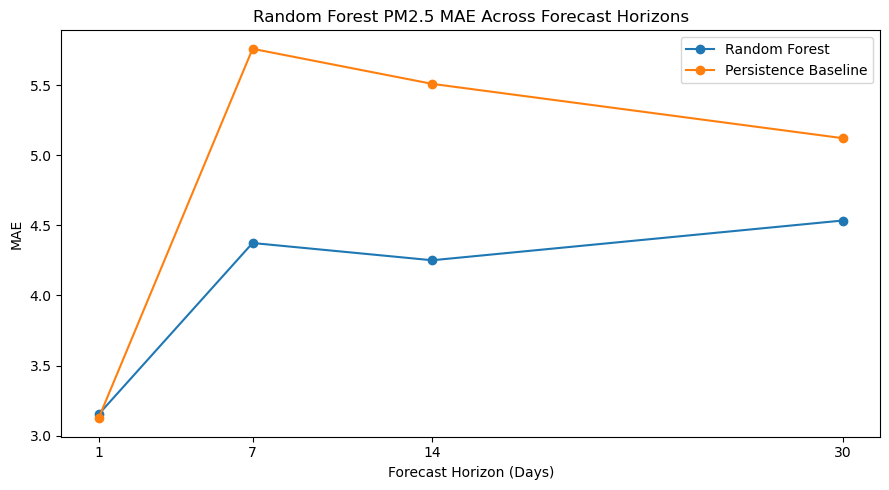

In [43]:

# ============================================================
# 17. MAE ACROSS FORECAST HORIZONS
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    results_df[
        "Horizon_Days"
    ],

    results_df[
        "MAE"
    ],

    marker="o",

    label="Random Forest"
)


plt.plot(

    results_df[
        "Horizon_Days"
    ],

    results_df[
        "Persistence_MAE"
    ],

    marker="o",

    label="Persistence Baseline"
)


plt.xlabel(
    "Forecast Horizon (Days)"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Random Forest PM2.5 MAE "
    "Across Forecast Horizons"
)

plt.xticks(
    FORECAST_HORIZONS
)

plt.legend()

plt.tight_layout()


plt.savefig(

    RESULTS_DIR
    /
    "rf_mae_across_horizons.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


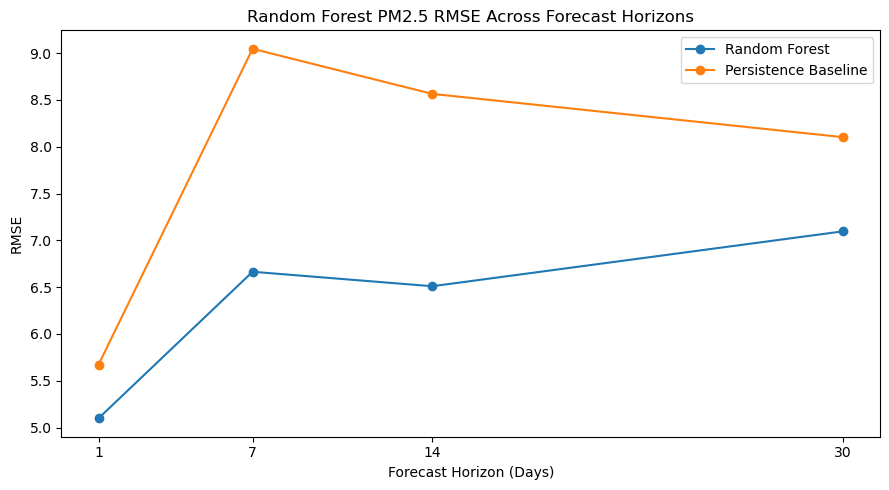

In [45]:

# ============================================================
# 18. RMSE ACROSS FORECAST HORIZONS
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    results_df[
        "Horizon_Days"
    ],

    results_df[
        "RMSE"
    ],

    marker="o",

    label="Random Forest"
)


plt.plot(

    results_df[
        "Horizon_Days"
    ],

    results_df[
        "Persistence_RMSE"
    ],

    marker="o",

    label="Persistence Baseline"
)


plt.xlabel(
    "Forecast Horizon (Days)"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Random Forest PM2.5 RMSE "
    "Across Forecast Horizons"
)

plt.xticks(
    FORECAST_HORIZONS
)

plt.legend()

plt.tight_layout()


plt.savefig(

    RESULTS_DIR
    /
    "rf_rmse_across_horizons.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()



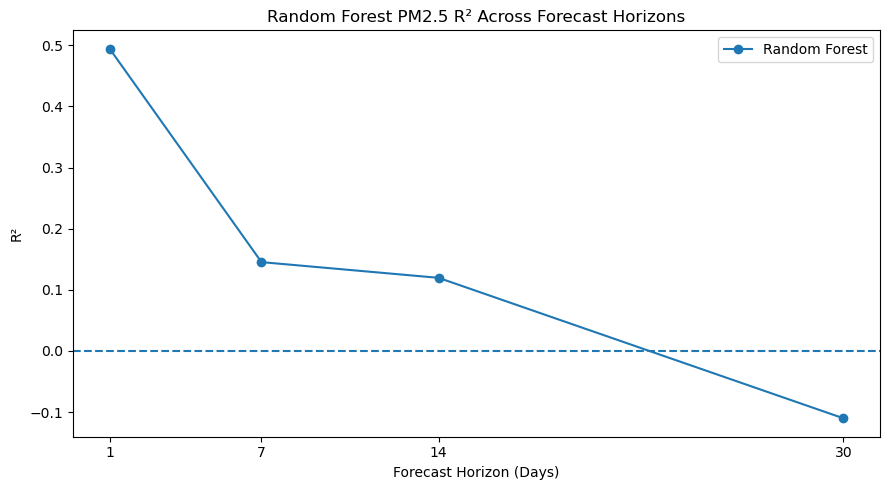

In [47]:

# ============================================================
# 19. R² ACROSS FORECAST HORIZONS
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    results_df[
        "Horizon_Days"
    ],

    results_df[
        "R2"
    ],

    marker="o",

    label="Random Forest"
)


plt.axhline(
    y=0,
    linestyle="--"
)


plt.xlabel(
    "Forecast Horizon (Days)"
)

plt.ylabel(
    "R²"
)

plt.title(
    "Random Forest PM2.5 R² "
    "Across Forecast Horizons"
)

plt.xticks(
    FORECAST_HORIZONS
)

plt.legend()

plt.tight_layout()


plt.savefig(

    RESULTS_DIR
    /
    "rf_r2_across_horizons.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


## Forecast trajectory and residual diagnostics

Aggregate metrics are complemented by observation-level diagnostics. Actual-versus-predicted time-series plots reveal whether the model follows temporal variation, misses episodic peaks, or produces overly smooth forecasts as the horizon increases.

Residuals are defined as

$$
e_i=y_i-\hat{y}_i.
$$

A well-calibrated regression model should ideally produce residuals distributed around zero without strong structure across the prediction range. Systematic curvature, changing residual variance, or clusters of large errors may indicate horizon-specific model limitations, unmodelled atmospheric processes, or difficulty reproducing extreme PM$_{2.5}$ events.


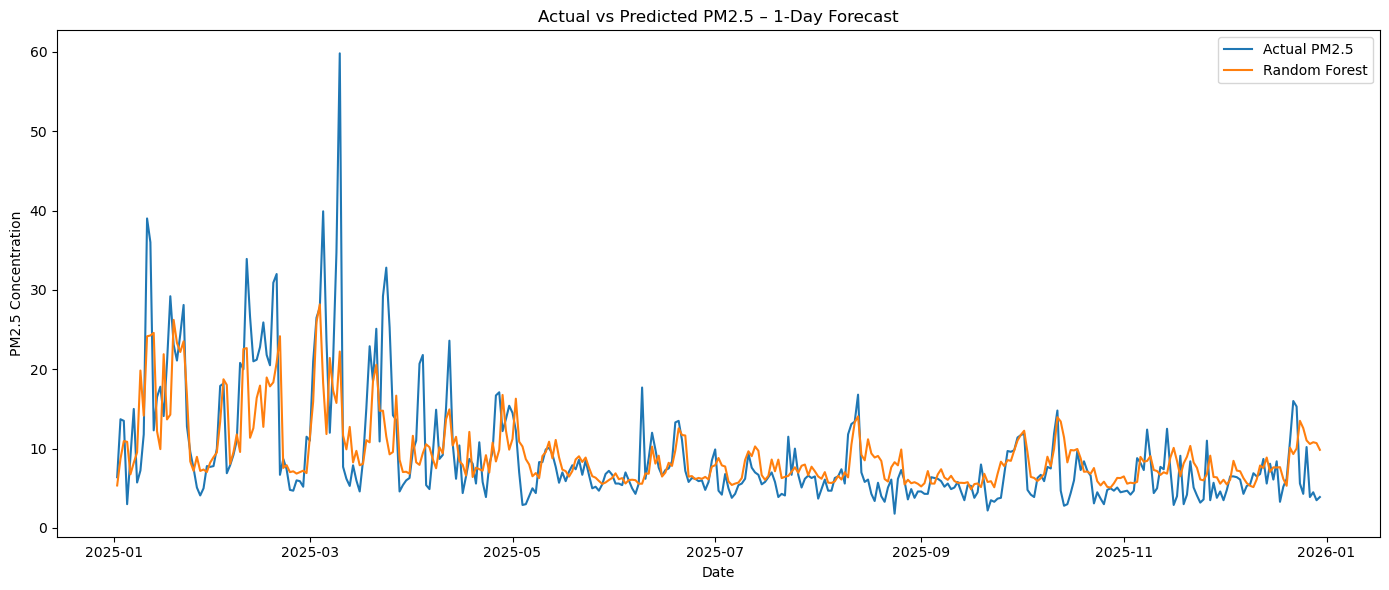

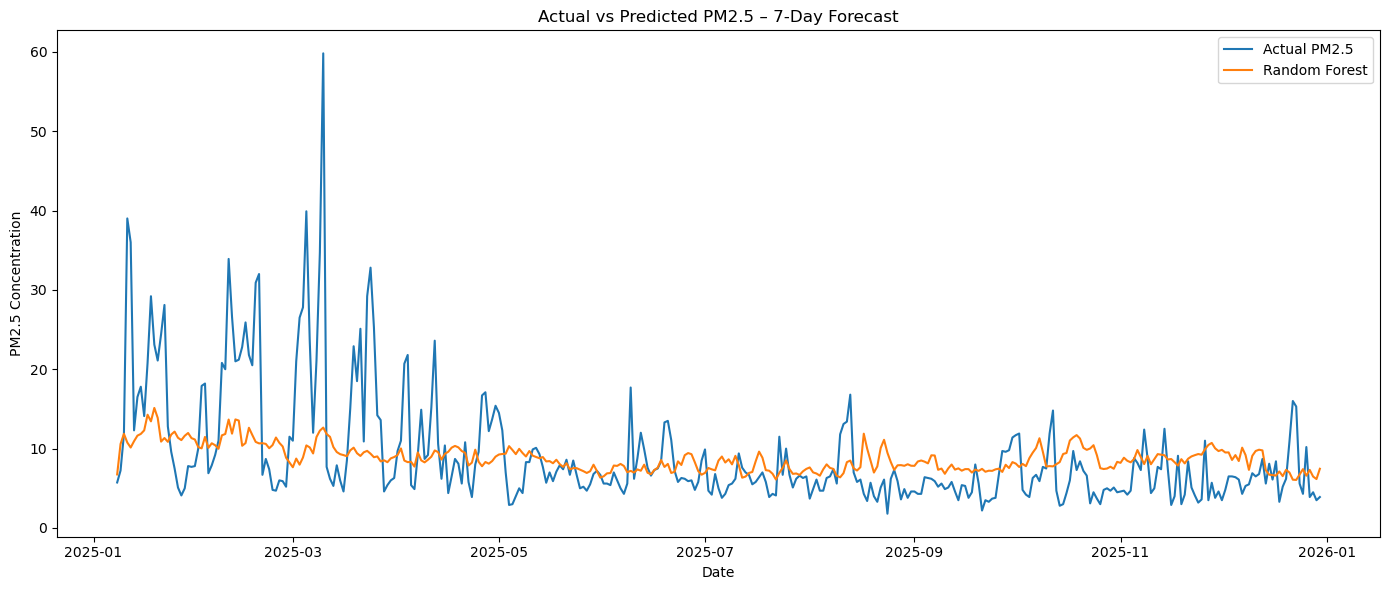

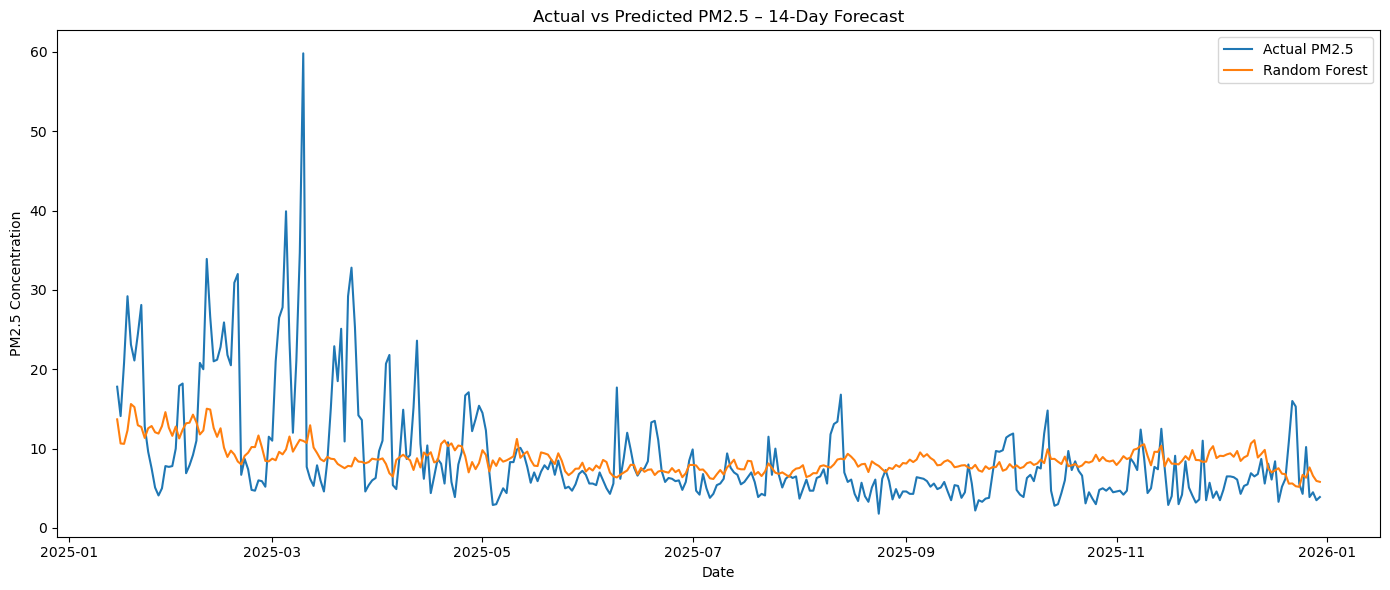

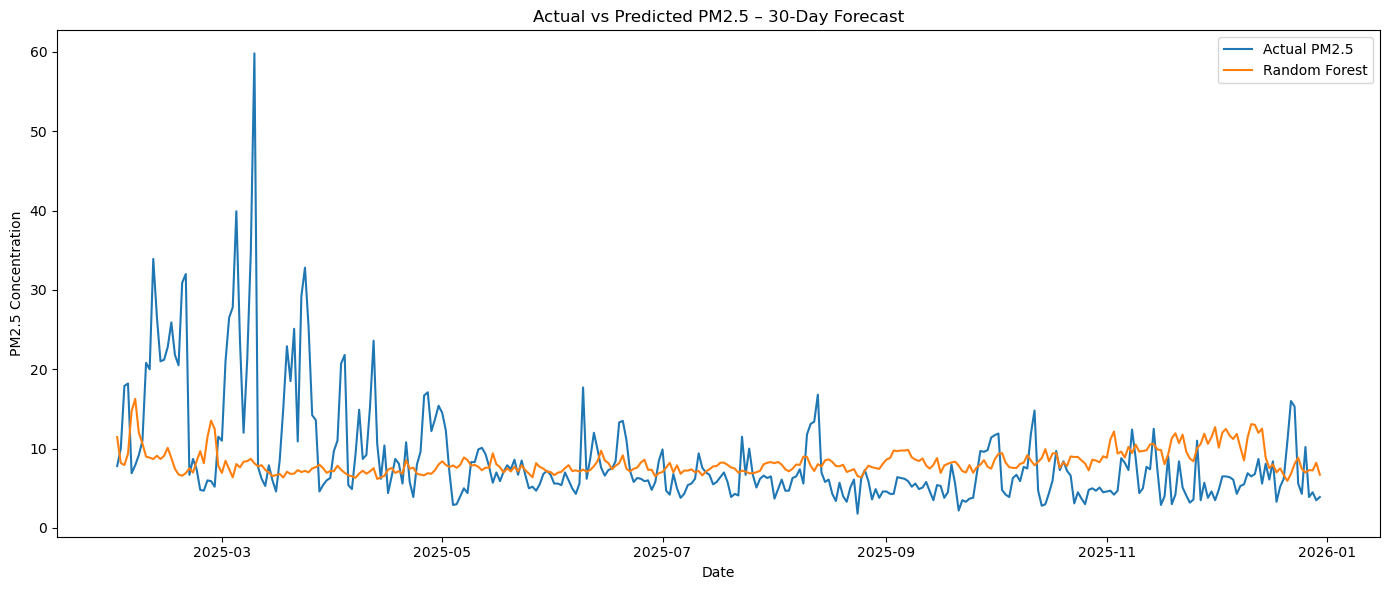

In [49]:
# ============================================================
# 20. ACTUAL VS PREDICTED PLOTS FOR ALL HORIZONS
# ============================================================

for horizon in FORECAST_HORIZONS:

    pred_df = prediction_data[
        horizon
    ]


    plt.figure(
        figsize=(14, 6)
    )


    plt.plot(

        pred_df[
            "Target_Date"
        ],

        pred_df[
            "Actual_PM25"
        ],

        label="Actual PM2.5"
    )


    plt.plot(

        pred_df[
            "Target_Date"
        ],

        pred_df[
            "Predicted_PM25"
        ],

        label="Random Forest"
    )


    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "PM2.5 Concentration"
    )


    plt.title(
        f"Actual vs Predicted PM2.5 "
        f"– {horizon}-Day Forecast"
    )


    plt.legend()

    plt.tight_layout()


    plt.savefig(

        RESULTS_DIR
        /
        f"rf_actual_vs_predicted_{horizon}d.png",

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()



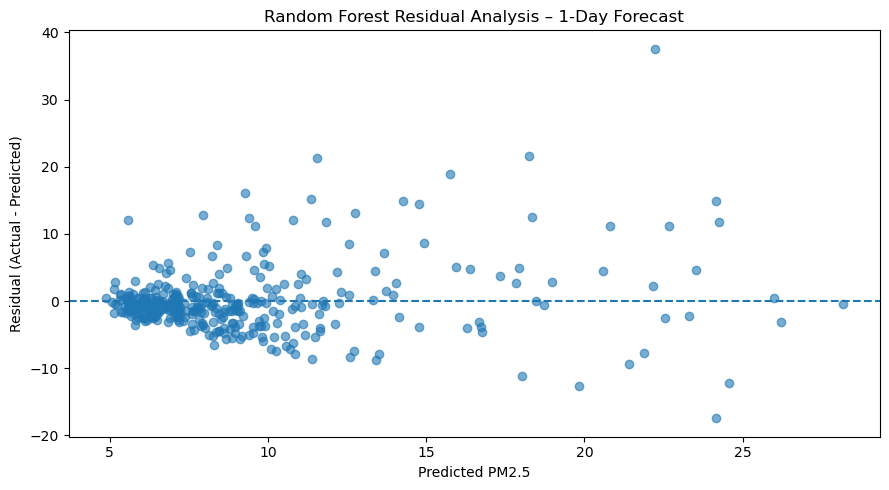

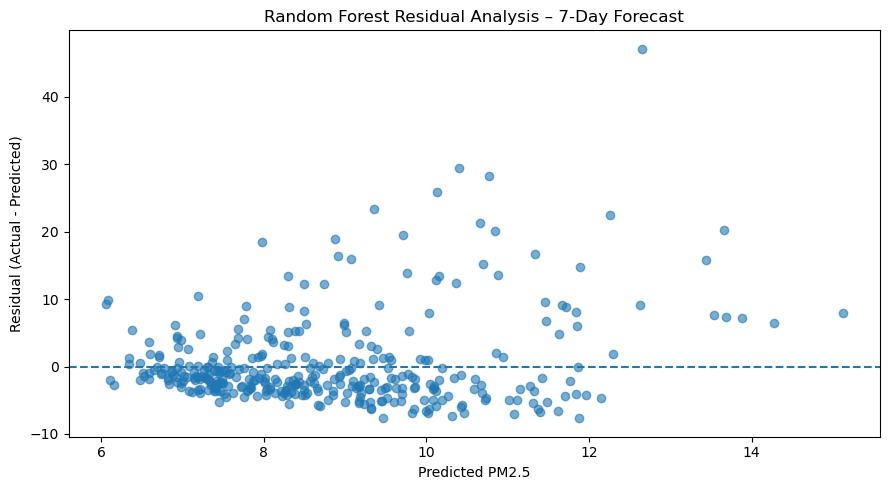

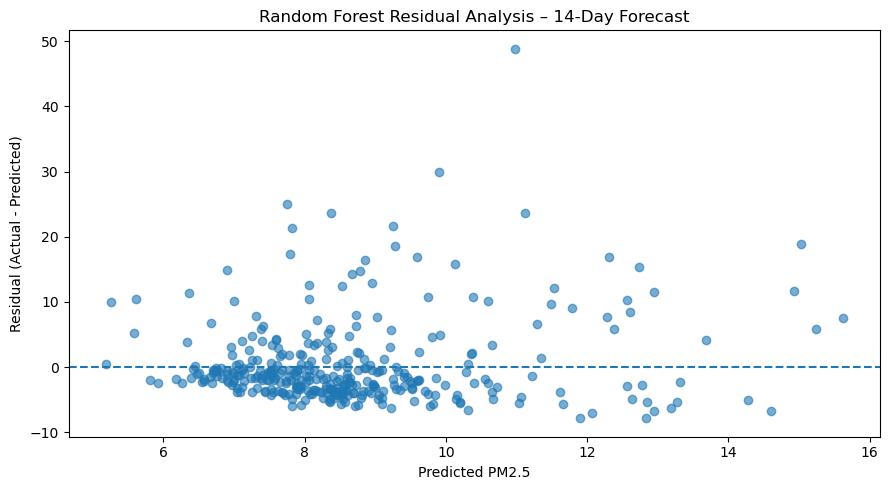

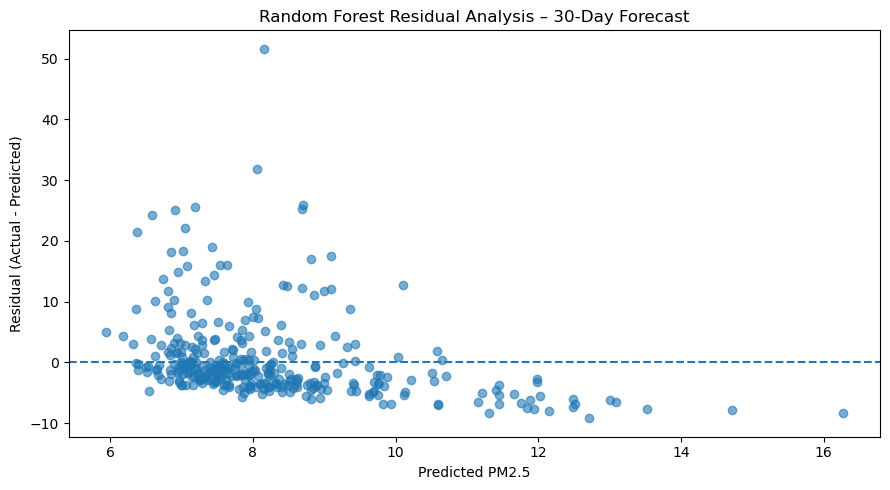

In [51]:
# ============================================================
# 21. RESIDUAL ANALYSIS FOR ALL HORIZONS
# ============================================================

for horizon in FORECAST_HORIZONS:

    pred_df = prediction_data[
        horizon
    ]


    plt.figure(
        figsize=(9, 5)
    )


    plt.scatter(

        pred_df[
            "Predicted_PM25"
        ],

        pred_df[
            "Residual"
        ],

        alpha=0.6
    )


    plt.axhline(
        y=0,
        linestyle="--"
    )


    plt.xlabel(
        "Predicted PM2.5"
    )

    plt.ylabel(
        "Residual (Actual - Predicted)"
    )


    plt.title(
        f"Random Forest Residual Analysis "
        f"– {horizon}-Day Forecast"
    )


    plt.tight_layout()


    plt.savefig(

        RESULTS_DIR
        /
        f"rf_residuals_{horizon}d.png",

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()



## Post-hoc interpretability using permutation importance

Permutation importance is used to quantify how strongly the fitted model depends on each predictor. For a given variable, its observed values are permuted while all other predictors are left unchanged; the resulting deterioration in predictive performance is then measured. Larger decreases in performance imply greater predictive reliance on that variable.

Importance is estimated separately for each horizon because the information supporting next-day forecasts may differ from that supporting multi-week forecasts. Short-horizon performance may depend more heavily on recent pollution dynamics, whereas longer-horizon performance may increasingly reflect seasonal or broader meteorological structure.

These importance values should be interpreted as **predictive associations within the fitted model**, not as estimates of causal influence. Because correlated variables can share or redistribute importance, emphasis should be placed on recurring patterns and physically plausible groups of predictors rather than on a single rank in isolation.


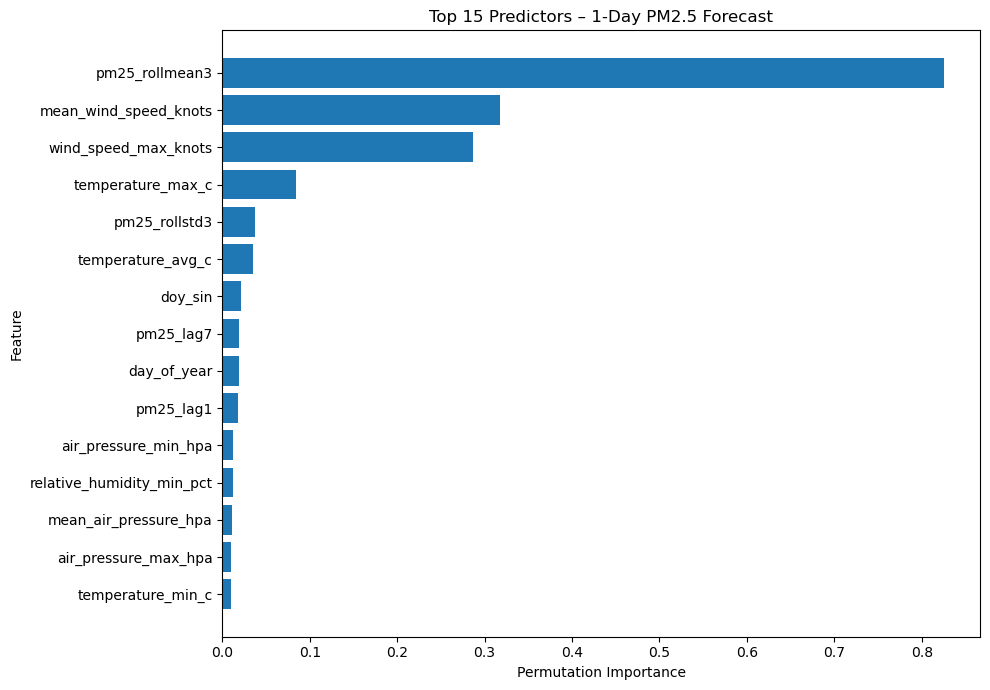

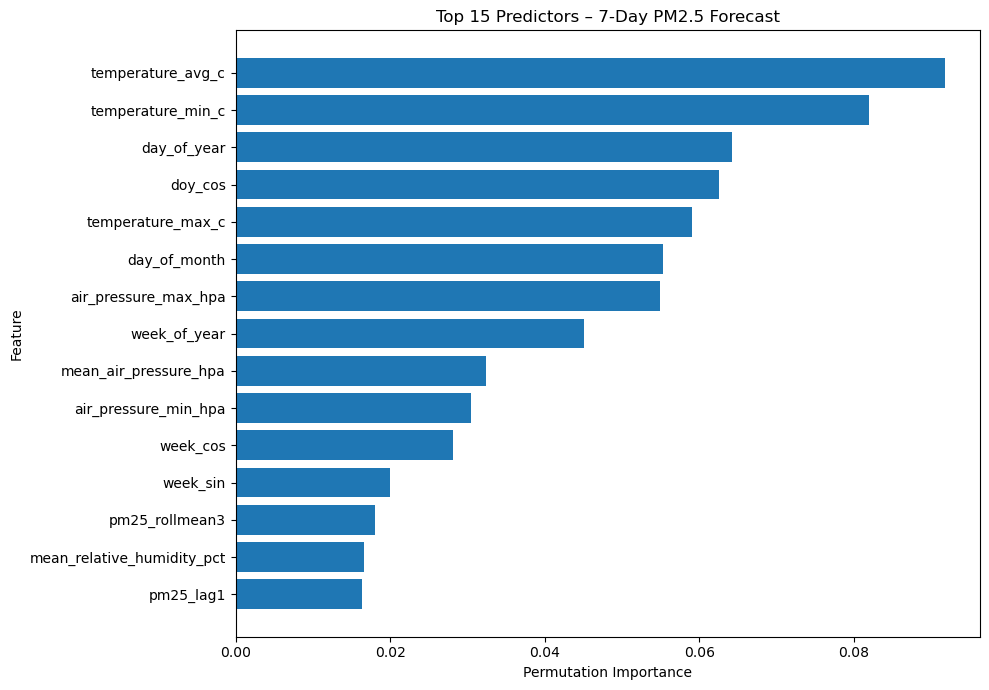

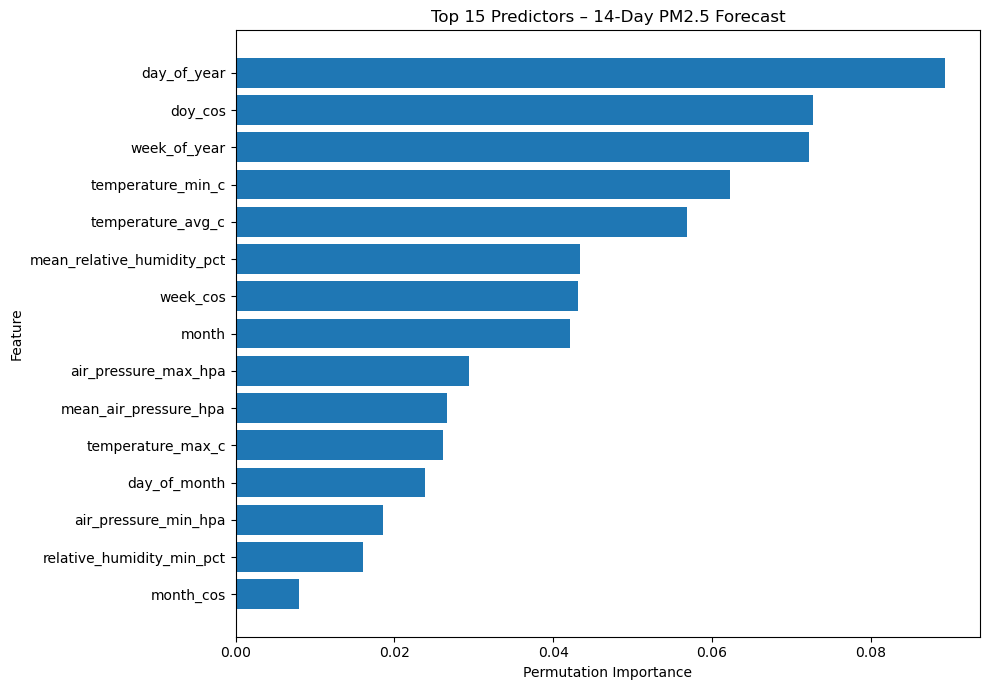

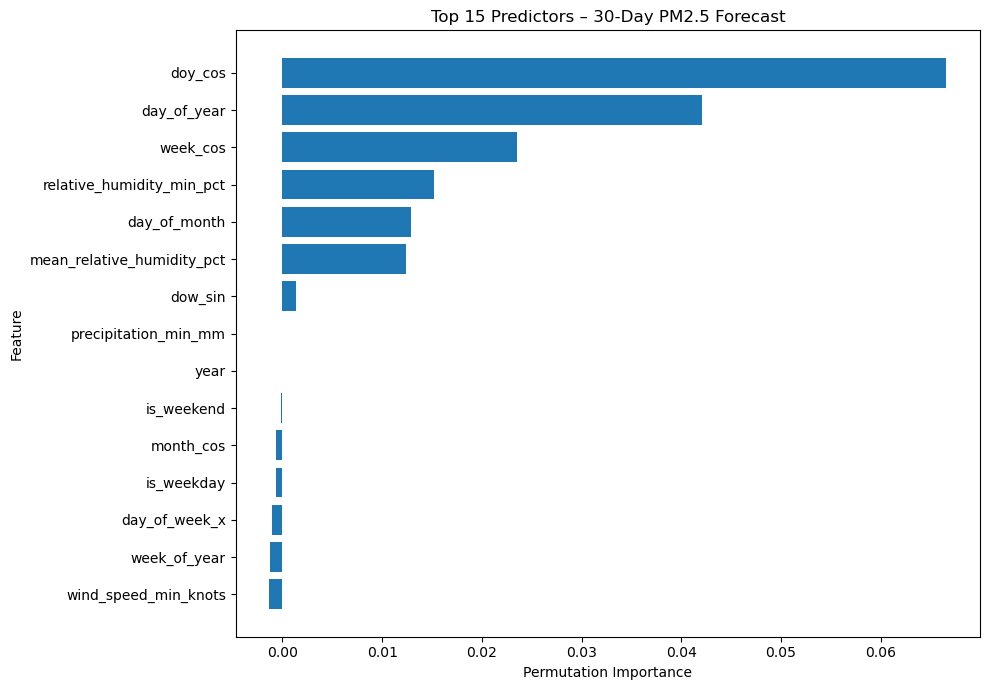

In [53]:
# ============================================================
# 22. PERMUTATION IMPORTANCE FOR EACH HORIZON
# ============================================================

for horizon in FORECAST_HORIZONS:

    importance_df = (
        permutation_importance_data[
            horizon
        ]
        .head(15)
        .sort_values(
            "Importance_Mean"
        )
    )


    plt.figure(
        figsize=(10, 7)
    )


    plt.barh(

        importance_df[
            "Feature"
        ],

        importance_df[
            "Importance_Mean"
        ]
    )


    plt.xlabel(
        "Permutation Importance"
    )

    plt.ylabel(
        "Feature"
    )


    plt.title(
        f"Top 15 Predictors "
        f"– {horizon}-Day PM2.5 Forecast"
    )


    plt.tight_layout()


    plt.savefig(

        RESULTS_DIR
        /
        f"rf_permutation_importance_{horizon}d.png",

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()


### Cross-horizon interpretation

The most informative feature-importance analysis is not simply the top-ranked predictor at one horizon, but whether the dominant information source changes as $h$ increases. A transition from recent PM$_{2.5}$ features toward seasonal and meteorological variables would suggest that the model moves from exploiting short-memory pollution dynamics to broader climatological structure at longer lead times. Any such conclusion should be based on the executed importance results and should be reported as an empirical pattern rather than a causal claim.


## Reproducibility and model artefacts

For each forecast horizon, the workflow stores the fitted estimator, test-set predictions, conventional Random Forest feature importance, permutation importance, and summary performance metrics. Retaining these artefacts supports reproducibility, model comparison, and subsequent error analysis without requiring the complete tuning procedure to be repeated.

The final results table should be used as the numerical source for any cross-model comparison. When comparing Random Forest with XGBoost or neural forecasting models, the comparison is valid only when models use the same target dates, forecast-horizon definition, holdout period, and metric conventions.


In [55]:
# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("RANDOM FOREST MODELLING COMPLETED")
print("=" * 80)


print(
    "\nSaved models:"
)

for horizon in FORECAST_HORIZONS:

    print(
        MODEL_DIR
        /
        f"random_forest_{horizon}d.joblib"
    )


print(
    "\nResults directory:",
    RESULTS_DIR.resolve()
)


print(
    "\nFinal performance:"
)


display(

    results_df[
        [
            "Horizon_Days",
            "CV_MAE",
            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "MAPE",
            "MBE",
            "Persistence_MAE",
            "Persistence_MSE",
            "Persistence_RMSE",
            "Persistence_R2",
            "Persistence_MAPE",
            "Persistence_MBE",
            "MAE_Improvement_Percent",
            "RMSE_Improvement_Percent"
        ]
    ].round(4)
)



RANDOM FOREST MODELLING COMPLETED

Saved models:
saved_con_rf/random_forest_1d.joblib
saved_con_rf/random_forest_7d.joblib
saved_con_rf/random_forest_14d.joblib
saved_con_rf/random_forest_30d.joblib

Results directory: /Users/hirunikeshika/AIR/notebooks/rf_results

Final performance:


,Horizon_Days,CV_MAE,MAE,MSE,RMSE,R2,MAPE,MBE,Persistence_MAE,Persistence_MSE,Persistence_RMSE,Persistence_R2,Persistence_MAPE,Persistence_MBE,MAE_Improvement_Percent,RMSE_Improvement_Percent
0,1,2.7942,3.1516,26.0081,5.0998,0.4944,41.3453,0.0655,3.1241,32.1905,5.6737,0.3742,37.6353,0.0003,-0.8814,10.1144
1,7,3.9117,4.3744,44.4142,6.6644,0.1454,54.6936,-0.3933,5.7599,81.8272,9.0458,-0.5746,71.4185,0.0804,24.0546,26.3264
2,14,3.9858,4.2512,42.3780,6.5098,0.1197,53.0528,-0.3486,5.5098,73.3518,8.5646,-0.5238,68.1618,0.2628,22.8424,23.9910
3,30,3.9449,4.5349,50.3543,7.0961,-0.1101,57.2381,-0.4793,5.1223,65.6488,8.1024,-0.4472,66.0931,0.6963,11.4675,12.4200
